In [20]:
!pip install pybullet

In [27]:
import pybullet as p
import pybullet_data
import random
import numpy as np
import pandas as pd

physicsClient = p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)
plane_id = p.loadURDF("plane.urdf")

sim_data = []

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [29]:
for i in range(1000):
    z_height = random.uniform(0.5, 10.0)
    orn = p.getQuaternionFromEuler([random.uniform(0, 2*np.pi) for _ in range(3)])
    obj_id = p.loadURDF("cube_small.urdf", [0, 0, z_height], orn)
    p.applyExternalForce(obj_id, -1, [random.uniform(-0.1, 0.1), 0, 0], [0, 0, 0], p.WORLD_FRAME)

    time_steps = 0
    impact = False
    while not impact and time_steps < 2000:
        p.stepSimulation()
        time_steps += 1
        pos, _ = p.getBasePositionAndOrientation(obj_id)
        lin_vel, _ = p.getBaseVelocity(obj_id)
        if pos[2] <= 0.03: # Detection height
            impact_velocity = abs(lin_vel[2])
            impact = True
    noise_lvl = 0.02
    noisy_time = time_steps * (1 + np.random.normal(0, noise_lvl))
    noisy_vel = impact_velocity * (1 + np.random.normal(0, noise_lvl))

    sim_data.append({
        'time_steps': noisy_time,
        'final_velocity': noisy_vel,
        'target_height': z_height
    })
    p.removeBody(obj_id)

p.disconnect()
df = pd.DataFrame(sim_data)

In [30]:
X = df[['time_steps', 'final_velocity']]
y = df['target_height']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Decision Tree": DecisionTreeRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "R2 Score": r2_score(y_test, preds)
    })

comparison_df = pd.DataFrame(results).sort_values(by="MAE")
print("\n--- Model Comparison Table ---")
print(comparison_df)


--- Model Comparison Table ---
               Model       MAE  R2 Score
1      Random Forest  0.313488  0.946354
2      Decision Tree  0.366786  0.925307
3                SVR  0.376115  0.883832
4                KNN  0.436706  0.901944
0  Linear Regression  0.630730  0.884890


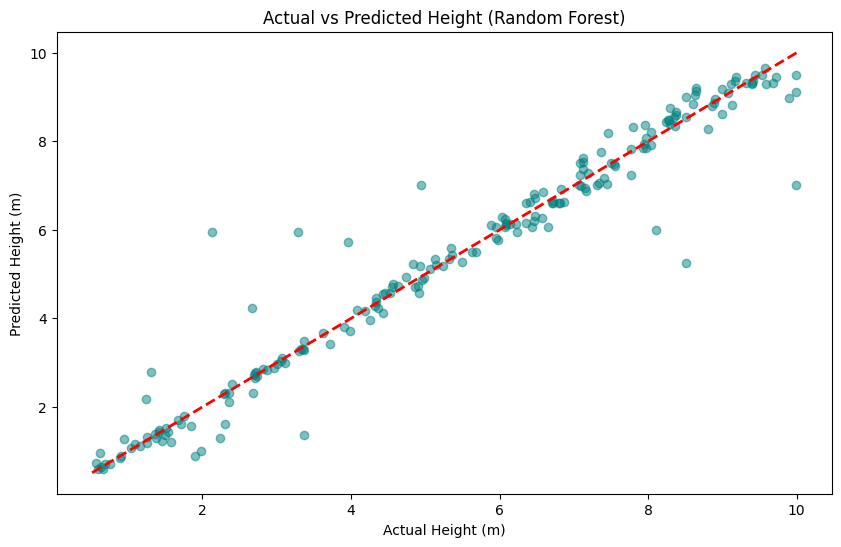

In [31]:
plt.figure(figsize=(10,6))
best_model = RandomForestRegressor().fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("Actual vs Predicted Height (Random Forest)")
plt.show()